# **FEATURE SELECTION PIPELINE**
---



In [ ]:
!pip install skrebate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from skrebate import ReliefF
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

In [ ]:
data = pd.read_excel('/content/dataset.xlsx')
print("Shape: ", data.shape)

features_df    = pd.read_csv('/content/FINAL_35_features_selected.csv')
FINAL_FEATURES = features_df['feature'].tolist()
N_FEATURES     = len(FINAL_FEATURES)

X = data[FINAL_FEATURES]
y = data['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Distributia datelor:")
print(f"X_train shape: {X_train.shape} ({X_train.shape[0]} paciente, {X_train.shape[1]} simptome)")
print(f"X_test shape:  {X_test.shape} ({X_test.shape[0]} paciente, {X_test.shape[1]} simptome)")
print(f"Prevalența bolii (Train): {y_train.mean()*100:.1f}%")
print(f"Prevalența bolii (Test):  {y_test.mean()*100:.1f}%")

Shape:  (886, 61)
Distributia datelor:
X_train shape: (708, 35) (708 paciente, 35 simptome)
X_test shape:  (178, 35) (178 paciente, 35 simptome)
Prevalența bolii (Train): 53.5%
Prevalența bolii (Test):  53.4%


Date incarcate: 886 paciente, 58 features
Distribuție clase: {1: np.int64(474), 0: np.int64(412)}
Train/Test Split (80/20) cu random_state=42
  Train set: 708 paciente, 58 features
  Test set: 178 paciente
  Train: {1: np.int64(379), 0: np.int64(329)}
  Test: {1: np.int64(95), 0: np.int64(83)}
Permutation Test — Prag Statistic (pe X_train, y_train)
  Generam distributia nula (100 permutari pe y_train)...
  Prag MI (p<0.05 equivalent): 0.0460
  41 features semnificative din 58

  ELIMINATE LA PASUL 1 (17 features):
  Motiv: Nu au trecut pragul statistic (p>0.05). Reprezinta zgomot pur.


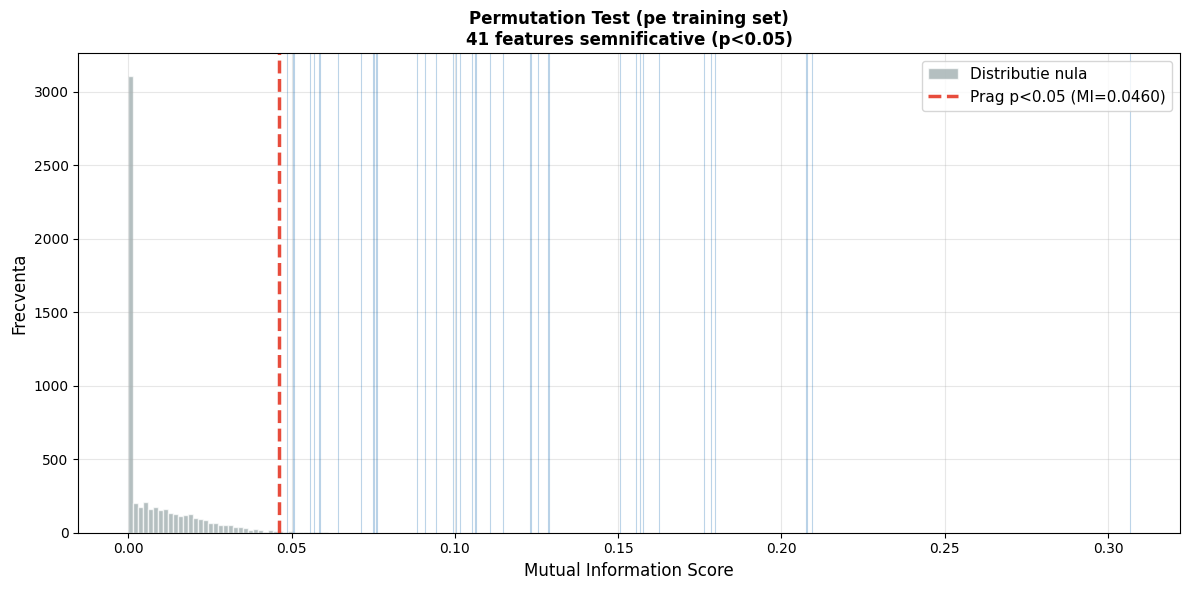

Univariate (Chi2+MI) -> Top 41 (pe X_train, y_train)
  41 features selectate
  Top 5: ['Menstrual pain (Dysmenorrhea)', 'Painful cramps during period', 'Painful / Burning pain during sex (Dyspareunia)', 'Fatigue / Chronic fatigue', 'Cramping']
ReliefF -> Top 41 (pe X_train, y_train)
  41 features selectate
  Top 5: ['Menstrual pain (Dysmenorrhea)', 'Painful cramps during period', 'Fatigue / Chronic fatigue', 'Painful / Burning pain during sex (Dyspareunia)', 'Pelvic pain']
Cross-Method Agreement (Intersectie)
  Univariate (Linear/Indep):  41 features
  ReliefF (Non-linear/K-NN):  41 features
  Consens (Intersectie):       37 features


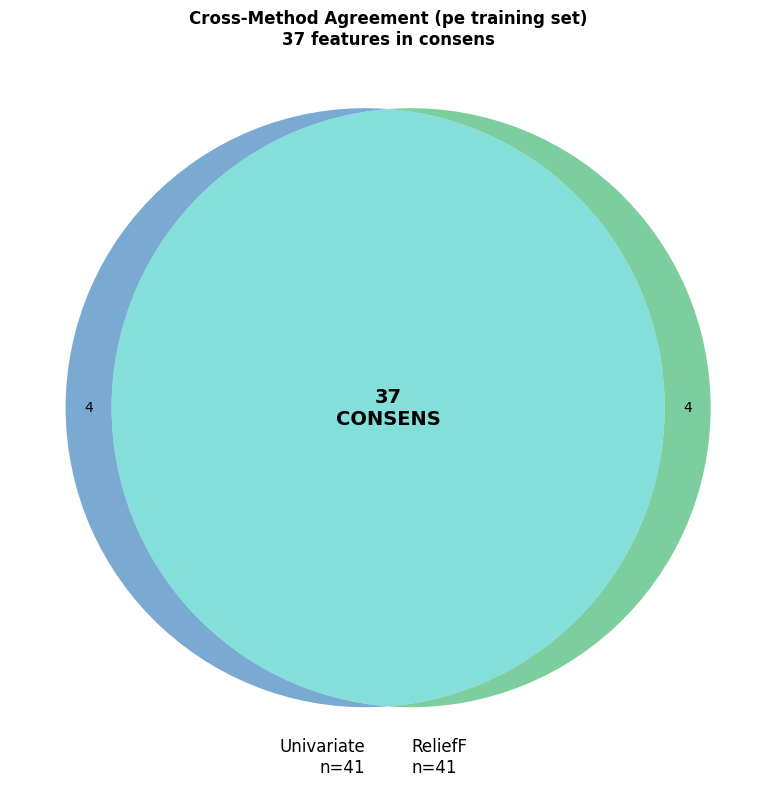

Eliminare Redundanta (Phi >= 0.70, pe X_train)
  [REDUNDANTA] Phi(Bleeding, Heavy / Extreme menstrual bleeding) = 0.850
    -> Scor 'Bleeding': 0.3267
    -> Scor 'Heavy / Extreme menstrual bleeding': 0.4504
    -> ELIMINAT: 'Bleeding' (scor mai mic)

  [REDUNDANTA] Phi(Back pain, Lower back pain) = 0.761
    -> Scor 'Back pain': 0.2332
    -> Scor 'Lower back pain': 0.2852
    -> ELIMINAT: 'Back pain' (scor mai mic)


  Rezultat: 37 -> 35 features finale (dupa eliminare redundanta)


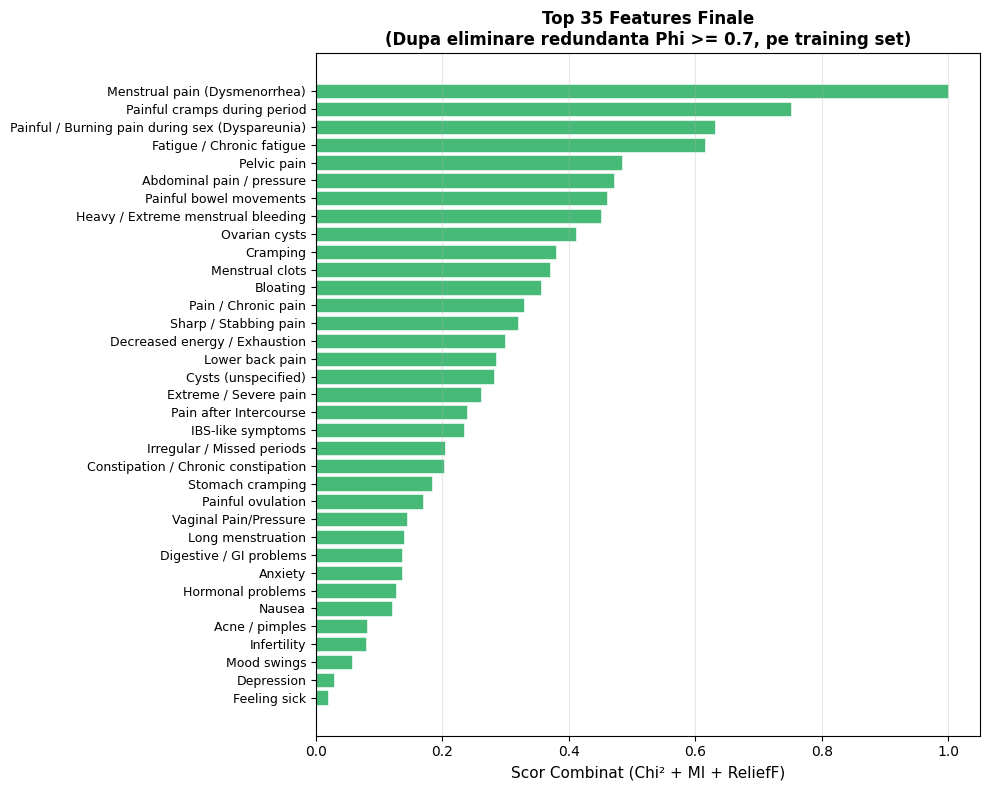

COMPLET — FEATURE SELECTION
  Reducere totala: 58 -> 35 (40%)

  Fisiere salvate:
    - Results/FINAL_35_features_selected.csv  (Lista features finale)
    - Results/FS_05_cma_scores_final.csv  (Scoruri combinate)
    - Results/FS_0X_*.csv  (Scoruri detaliate)
    - Figures/FS_0X_*.png  (Grafice vizualizare)


In [ ]:
BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
RESULTS_DIR = os.path.join(BASE_DIR, 'Results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

dataset_path = "/content/dataset.xlsx"
if not os.path.exists(dataset_path):
    print("EROARE: Nu exista fisierul 'dataset.xlsx'. Te rog incarca-l in /content/")
else:
    df = pd.read_excel(dataset_path, engine="openpyxl")
    y = df["label"].astype(int)
    X = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')

    feature_names = list(X.columns)
    N_FEATURES = len(feature_names)
    print(f"Date incarcate: {X.shape[0]} paciente, {N_FEATURES} features")
    print(f"Distribuție clase: {dict(y.value_counts())}")

    print("Train/Test Split (80/20) cu random_state=42")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    print(f"  Train set: {X_train.shape[0]} paciente, {X_train.shape[1]} features")
    print(f"  Test set: {X_test.shape[0]} paciente")
    print(f"  Train: {dict(y_train.value_counts())}")
    print(f"  Test: {dict(y_test.value_counts())}")
    print("Permutation Test — Prag Statistic (pe X_train, y_train)")

    np.random.seed(42)
    mi_real = mutual_info_classif(X_train, y_train, random_state=42)
    mi_series = pd.Series(mi_real, index=feature_names)

    null_distribution = []
    print("  Generam distributia nula (100 permutari pe y_train)...")
    for i in range(100):
        y_perm = np.random.permutation(y_train)
        null_distribution.extend(
            mutual_info_classif(X_train, y_perm, random_state=None))

    MI_THRESHOLD = np.percentile(null_distribution, 99)
    K_significant = int(sum(mi_real > MI_THRESHOLD))
    TOP_K = K_significant

    print(f"  Prag MI (p<0.05 equivalent): {MI_THRESHOLD:.4f}")
    print(f"  {K_significant} features semnificative din {N_FEATURES}")

    features_step1 = set(mi_series[mi_series > MI_THRESHOLD].index)
    dropped_step1 = set(feature_names) - features_step1
    print(f"\n  ELIMINATE LA PASUL 1 ({len(dropped_step1)} features):")
    print(f"  Motiv: Nu au trecut pragul statistic (p>0.05). Reprezinta zgomot pur.")

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(null_distribution, bins=50, color='#95a5a6',
            alpha=0.7, edgecolor='white', label='Distributie nula')
    ax.axvline(x=MI_THRESHOLD, color='#E74C3C', linewidth=2.5,
               linestyle='--', label=f'Prag p<0.05 (MI={MI_THRESHOLD:.4f})')
    for mi_val in mi_series.values:
        if mi_val > MI_THRESHOLD:
            ax.axvline(x=mi_val, color='#2171B5', alpha=0.3, linewidth=0.8)
    ax.set_xlabel('Mutual Information Score', fontsize=12)
    ax.set_ylabel('Frecventa', fontsize=12)
    ax.set_title(f'Permutation Test (pe training set)\n{K_significant} features semnificative (p<0.05)',
                 fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'FS_01_permutation_test.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Univariate (Chi2+MI) -> Top {TOP_K} (pe X_train, y_train)")

    X_train_nonneg = MinMaxScaler().fit_transform(X_train)
    chi2_scores, _ = chi2(X_train_nonneg, y_train)
    scores_chi2 = pd.Series(chi2_scores, index=feature_names)
    scores_mi   = mi_series

    rank_chi2 = scores_chi2.rank(ascending=False)
    rank_mi   = scores_mi.rank(ascending=False)
    rank_univ = (rank_chi2 + rank_mi) / 2

    univariate_df = pd.DataFrame({
        'Feature':    feature_names,
        'Chi2_score': chi2_scores,
        'MI_score':   scores_mi.values,
        'Rank_Chi2':  rank_chi2.values,
        'Rank_MI':    rank_mi.values,
        'Rank_Univ':  rank_univ.values
    }).sort_values('Rank_Univ')

    features_univariate = set(univariate_df.head(TOP_K)['Feature'])
    print(f"  {len(features_univariate)} features selectate")
    print(f"  Top 5: {list(univariate_df.head(5)['Feature'])}")
    univariate_df.to_csv(os.path.join(RESULTS_DIR, 'FS_02_univariate_scores.csv'), index=False)

    print(f"ReliefF -> Top {TOP_K} (pe X_train, y_train)")

    X_train_scaled = MinMaxScaler().fit_transform(X_train)
    relief = ReliefF(n_neighbors=10)
    relief.fit(X_train_scaled, y_train.values)

    relief_scores = pd.Series(
        relief.feature_importances_, index=feature_names
    ).sort_values(ascending=False)

    features_relief = set(relief_scores.head(TOP_K).index)
    print(f"  {len(features_relief)} features selectate")
    print(f"  Top 5: {list(relief_scores.head(5).index)}")

    relief_df = pd.DataFrame({
        'Feature': feature_names,
        'ReliefF_score': relief.feature_importances_
    }).sort_values('ReliefF_score', ascending=False)
    relief_df.to_csv(os.path.join(RESULTS_DIR, 'FS_03_relieff_scores.csv'), index=False)

    print("Cross-Method Agreement (Intersectie)")

    cma_features = features_univariate & features_relief
    only_univ = features_univariate - features_relief
    only_rel  = features_relief - features_univariate

    print(f"  Univariate (Linear/Indep):  {len(features_univariate)} features")
    print(f"  ReliefF (Non-linear/K-NN):  {len(features_relief)} features")
    print(f"  Consens (Intersectie):       {len(cma_features)} features")

    fig, ax = plt.subplots(figsize=(10, 8))
    venn = venn2(
        subsets=[features_univariate, features_relief],
        set_labels=(f'Univariate\nn={len(features_univariate)}',
                    f'ReliefF\nn={len(features_relief)}'),
        set_colors=('#2171B5', '#27AE60'), alpha=0.6, ax=ax)
    if venn.get_label_by_id('11'):
        venn.get_label_by_id('11').set_text(f'{len(cma_features)}\nCONSENS')
        venn.get_label_by_id('11').set_fontsize(14)
        venn.get_label_by_id('11').set_fontweight('bold')
    ax.set_title(f'Cross-Method Agreement (pe training set)\n{len(cma_features)} features in consens',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'FS_04_venn_cma.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Eliminare Redundanta (Phi >= 0.70, pe X_train)")

    cma_list = sorted(cma_features)

    cma_scores = pd.DataFrame({'Feature': cma_list})
    chi2_vals   = scores_chi2[cma_list]
    mi_vals     = scores_mi[cma_list]
    relief_vals = relief_scores[cma_list]

    cma_scores['Chi2_norm'] = (chi2_vals.values - chi2_vals.min()) / (chi2_vals.max() - chi2_vals.min() + 1e-12)
    cma_scores['MI_norm']   = (mi_vals.values - mi_vals.min()) / (mi_vals.max() - mi_vals.min() + 1e-12)
    cma_scores['ReliefF_norm'] = (relief_vals.values - relief_vals.min()) / (relief_vals.max() - relief_vals.min() + 1e-12)

    cma_scores['Combined_Score'] = (cma_scores['Chi2_norm'] + cma_scores['MI_norm'] + cma_scores['ReliefF_norm']) / 3
    score_dict = dict(zip(cma_scores['Feature'], cma_scores['Combined_Score']))

    X_train_cma = X_train[cma_list]
    corr_matrix = X_train_cma.corr().abs()

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    CORR_THRESHOLD = 0.70
    features_to_drop = set()

    for col in upper_tri.columns:
        for row in upper_tri.index:
            phi_val = upper_tri.loc[row, col]
            if phi_val >= CORR_THRESHOLD:
                f1, f2 = row, col
                if score_dict[f1] < score_dict[f2]:
                    dropped, kept = f1, f2
                else:
                    dropped, kept = f2, f1

                features_to_drop.add(dropped)
                print(f"  [REDUNDANTA] Phi({f1}, {f2}) = {phi_val:.3f}")
                print(f"    -> Scor '{f1}': {score_dict[f1]:.4f}")
                print(f"    -> Scor '{f2}': {score_dict[f2]:.4f}")
                print(f"    -> ELIMINAT: '{dropped}' (scor mai mic)\n")

    FINAL_FEATURES = [f for f in cma_list if f not in features_to_drop]
    K_final = len(FINAL_FEATURES)

    cma_scores['Status'] = cma_scores['Feature'].apply(
        lambda x: 'ELIMINAT (Redundanta)' if x in features_to_drop else 'PASTRAT')

    cma_scores = cma_scores.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
    cma_scores.index += 1

    print(f"\n  Rezultat: {len(cma_list)} -> {K_final} features finale (dupa eliminare redundanta)")

    fig, ax = plt.subplots(figsize=(10, 8))
    top_df = cma_scores[cma_scores['Status'] == 'PASTRAT'].copy()

    ax.barh(range(len(top_df)),
            top_df['Combined_Score'].values[::-1],
            color='#27AE60', alpha=0.85,
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels(top_df['Feature'].values[::-1], fontsize=9)
    ax.set_xlabel('Scor Combinat (Chi² + MI + ReliefF)', fontsize=11)
    ax.set_title(f'Top {K_final} Features Finale\n(Dupa eliminare redundanta Phi >= {CORR_THRESHOLD}, pe training set)',
                 fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'FS_05_final_features.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    pd.Series(FINAL_FEATURES, name='feature').to_csv(
        os.path.join(RESULTS_DIR, f'FINAL_{K_final}_features_selected.csv'), index=False)
    cma_scores.to_csv(
        os.path.join(RESULTS_DIR, 'FS_05_cma_scores_final.csv'), index=False)

    print("COMPLET — FEATURE SELECTION")
    print(f"  Reducere totala: {N_FEATURES} -> {K_final} "
          f"({(1-K_final/N_FEATURES)*100:.0f}%)")
    print(f"\n  Fisiere salvate:")
    print(f"    - Results/FINAL_{K_final}_features_selected.csv  (Lista features finale)")
    print(f"    - Results/FS_05_cma_scores_final.csv  (Scoruri combinate)")
    print(f"    - Results/FS_0X_*.csv  (Scoruri detaliate)")
    print(f"    - Figures/FS_0X_*.png  (Grafice vizualizare)")